# Automatic Caption Generation for the Corel5K Dataset Using BLIP

This notebook generates image captions for the Corel5K dataset using the BLIP (Bootstrapping Language-Image Pretraining) model. The generated captions are later used as textual descriptions in the semi-supervised image classification pipeline proposed in the paper.

## Dataset

This notebook assumes that the Corel5K dataset archive (`corel5k_images.7z`) has been downloaded from the Zenodo repository and placed in the `data/` directory.

The following cell verifies that the archive exists and extracts it if necessary.

In [ ]:
from pathlib import Path
import subprocess

DATA_DIR = Path("../data")
ARCHIVE = DATA_DIR / "corel5k_images.7z"
EXTRACT_DIR = DATA_DIR / "corel5k_images"

if not ARCHIVE.exists():
    raise FileNotFoundError(
        "corel5k_images.7z was not found.\n"
        "Please download it from the Zenodo repository and place it in the data/ directory."
    )

if EXTRACT_DIR.exists():
    print("Dataset already extracted.")
else:
    subprocess.run(
        ["7z", "x", str(ARCHIVE), f"-o{DATA_DIR}"],
        check=True
    )
    print("Dataset extracted successfully.")

Mounted at /content/drive


## PyTorch Dataset

This section defines a custom PyTorch dataset for loading the Corel5K images. Each image is resized to the input resolution required by the BLIP model and converted to a PyTorch tensor. A `DataLoader` is then created to efficiently iterate over the dataset in batches during caption generation.

In [ ]:
from pathlib import Path
import os

from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

IMAGE_DIR = DATA_DIR / "corel5k_images"


class Corel5KDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = Path(root_dir)
        self.transform = transform

        self.images = [
            f for f in os.listdir(self.root_dir)
            if f.endswith(".jpg")
        ]

        self.images.sort(key=lambda x: int(Path(x).stem))

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image_path = self.root_dir / self.images[idx]

        image = Image.open(image_path).convert("RGB")

        if self.transform is not None:
            image = self.transform(image)

        return image, self.images[idx]


transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

dataset = Corel5KDataset(IMAGE_DIR, transform=transform)

dataloader = DataLoader(
    dataset,
    batch_size=16,
    shuffle=False,
)

In [ ]:
images, image_names = next(iter(dataloader))

print(images.shape)
print(image_names[:5])

<class 'torch.Tensor'>
torch.Size([16, 3, 224, 224])


## Load the BLIP Model

This section loads the pre-trained BLIP image captioning model and its corresponding processor from Hugging Face. The model is configured to run on a GPU when available; otherwise, it falls back to the CPU.

In [ ]:
from transformers import BlipProcessor, BlipForConditionalGeneration
from PIL import Image
import matplotlib.pyplot as plt
import torch

MODEL_NAME = "Salesforce/blip-image-captioning-base"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

processor = BlipProcessor.from_pretrained(MODEL_NAME)

model = BlipForConditionalGeneration.from_pretrained(
    MODEL_NAME
).to(device)

model.eval()

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


Usando dispositivo: cuda


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/287 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/506 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/990M [00:00<?, ?B/s]

BlipForConditionalGeneration(
  (vision_model): BlipVisionModel(
    (embeddings): BlipVisionEmbeddings(
      (patch_embedding): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
    )
    (encoder): BlipEncoder(
      (layers): ModuleList(
        (0-11): 12 x BlipEncoderLayer(
          (self_attn): BlipAttention(
            (dropout): Dropout(p=0.0, inplace=False)
            (qkv): Linear(in_features=768, out_features=2304, bias=True)
            (projection): Linear(in_features=768, out_features=768, bias=True)
          )
          (layer_norm1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
          (mlp): BlipMLP(
            (activation_fn): GELUActivation()
            (fc1): Linear(in_features=768, out_features=3072, bias=True)
            (fc2): Linear(in_features=3072, out_features=768, bias=True)
          )
          (layer_norm2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        )
      )
    )
    (post_layernorm): LayerNorm((768,), eps=1e-0

## Generate Image Captions

This section processes the Corel5K dataset in batches using the BLIP model. For each batch, image captions are generated and stored in a Pandas DataFrame along with the corresponding image filenames.

To improve memory management, intermediate tensors are released after each batch, and the GPU cache is cleared when CUDA is available.

In [ ]:
import pandas as pd
import torch
import gc
from torchvision import transforms

all_captions = []
all_image_names = []

max_batches = 3 

def generate_captions(batch):
    images, image_names = batch

    pil_images = [transforms.ToPILImage()(img) for img in images]

    inputs = processor(
        pil_images,
        return_tensors="pt",
        padding=True
    ).to(device)

    with torch.no_grad():
        outputs = model.generate(**inputs, max_new_tokens=20)
        captions = [
            processor.decode(output, skip_special_tokens=True)
            for output in outputs
        ]

    return image_names, captions, inputs, outputs

for i, batch in enumerate(dataloader):
    image_names, captions, inputs, outputs = generate_captions(batch)

    all_captions.extend(captions)
    all_image_names.extend(image_names)

    print(f"Processed batch {i + 1}")

    inputs = inputs.to("cpu")
    outputs = outputs.to("cpu")

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    gc.collect()

    # if i + 1 >= max_batches:
    #     break

df_result = pd.DataFrame({
    "image": all_image_names,
    "caption": all_captions,
})

df_result["caption"] = df_result["caption"].apply(
    lambda caption: f'"{caption}"'
)

df_result.head()

model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

Batch 1 processado
Batch 2 processado
Batch 3 processado
Batch 4 processado
Batch 5 processado
Batch 6 processado
Batch 7 processado
Batch 8 processado
Batch 9 processado
Batch 10 processado
Batch 11 processado
Batch 12 processado
Batch 13 processado
Batch 14 processado
Batch 15 processado
Batch 16 processado
Batch 17 processado
Batch 18 processado
Batch 19 processado
Batch 20 processado
Batch 21 processado
Batch 22 processado
Batch 23 processado
Batch 24 processado
Batch 25 processado
Batch 26 processado
Batch 27 processado
Batch 28 processado
Batch 29 processado
Batch 30 processado
Batch 31 processado
Batch 32 processado
Batch 33 processado
Batch 34 processado
Batch 35 processado
Batch 36 processado
Batch 37 processado
Batch 38 processado
Batch 39 processado
Batch 40 processado
Batch 41 processado
Batch 42 processado
Batch 43 processado
Batch 44 processado
Batch 45 processado
Batch 46 processado
Batch 47 processado
Batch 48 processado
Batch 49 processado
Batch 50 processado
Batch 51 

,imagem,legenda
0,1.jpg,"""a stained glass window with a circular design"""
1,2.jpg,"""a stained window with a floral design"""
2,3.jpg,"""a stained glass window in the cathedral"""
3,4.jpg,"""a stained glass window with a man in it"""
4,5.jpg,"""a stained glass window with a cross in the ce..."


## Save Captions

The generated captions are saved as a CSV file in the `results/` directory. This file is used as input for the subsequent stages of the proposed pipeline.

In [ ]:
from pathlib import Path

RESULTS_DIR = Path("../results")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

OUTPUT_FILE = RESULTS_DIR / "captions.csv"

df_result.to_csv(
    OUTPUT_FILE,
    index=False
)

print(f"Captions saved to: {OUTPUT_FILE.resolve()}")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Preview Results

In [ ]:
df_result

,imagem,legenda
0,1.jpg,"""a stained glass window with a circular design"""
1,2.jpg,"""a stained window with a floral design"""
2,3.jpg,"""a stained glass window in the cathedral"""
3,4.jpg,"""a stained glass window with a man in it"""
4,5.jpg,"""a stained glass window with a cross in the ce..."
...,...,...
4995,4996.jpg,"""a blue and orange pattern with a black backgr..."
4996,4997.jpg,"""a blue and red tree with a red background"""
4997,4998.jpg,"""two circular glass buttons with a red backgro..."
4998,4999.jpg,"""a purple background with a pattern of flowers"""


## Visualize Generated Captions

This section randomly selects a subset of images from the generated captions file and displays a sample of them alongside their corresponding captions. This qualitative inspection helps assess the quality of the captions produced by the BLIP model.

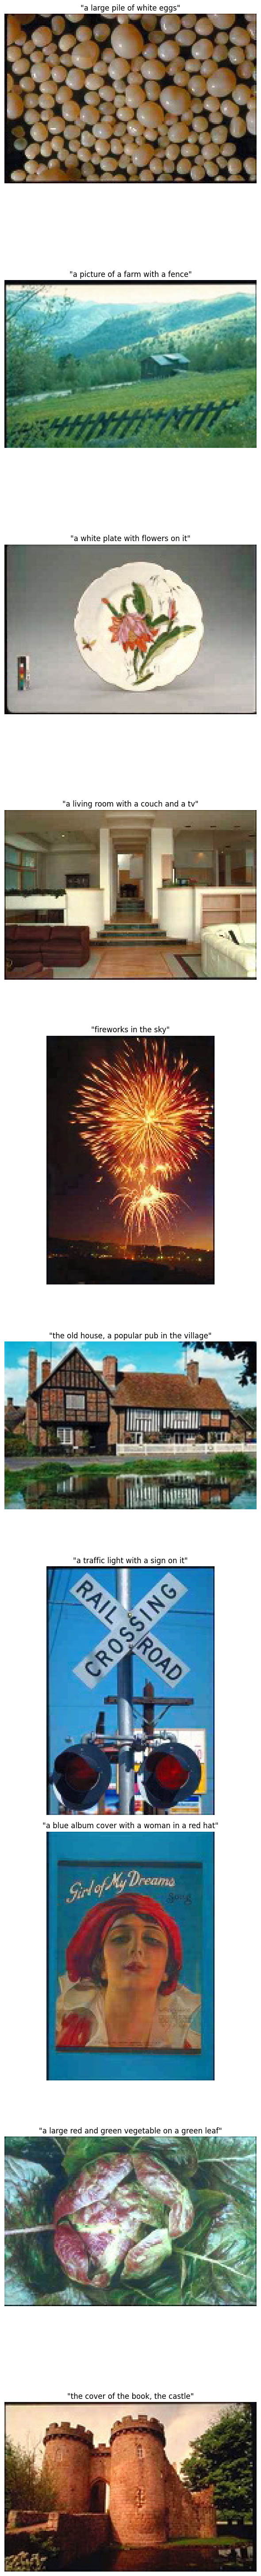

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import os
import pandas as pd

df_result = pd.read_csv(OUTPUT_FILE)

df_sampled = df_result.sample(100)

SHOW_IMAGES = 10

fig, axes = plt.subplots(
    SHOW_IMAGES,
    1,
    figsize=(6, 6 * SHOW_IMAGES)
)

for i, (_, row) in enumerate(df_sampled.iterrows()):
    if i >= SHOW_IMAGES:
        break

    image_path = IMAGE_DIR / row["image"]

    image = Image.open(image_path).convert("RGB")

    axes[i].imshow(image)
    axes[i].set_title(row["caption"], fontsize=12)
    axes[i].axis("off")

plt.tight_layout()
plt.show()